In [55]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('Pokemon.csv')
data = data.set_index('#')

In [56]:
data.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## EDA

In [3]:
data2 = data.copy(deep=True)
del data2['Legendary']
del data2['Generation']
del data2['Total']

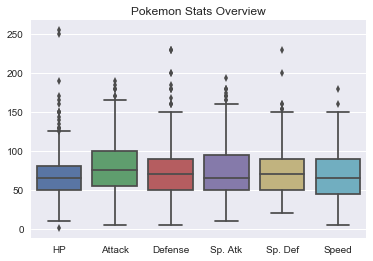

In [4]:
%matplotlib inline
sns.boxplot(data=data2)
plt.title("Pokemon Stats Overview")

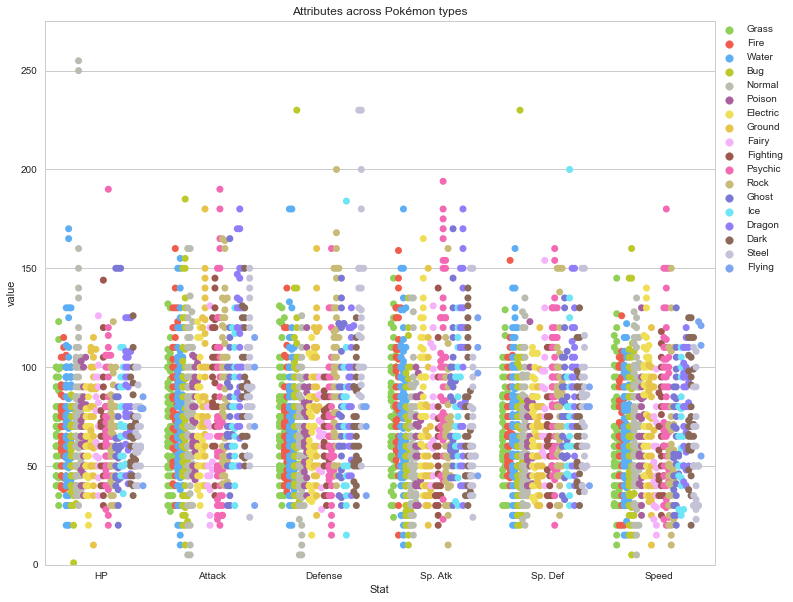

In [5]:
#https://www.kaggle.com/ndrewgele/visualizing-pok-mon-stats-with-seaborn
pkmn = pd.melt(data2, id_vars=["Name", "Type 1", "Type 2"], var_name="Stat")
sns.set_style("whitegrid")
with sns.color_palette([
    "#8ED752", "#F95643", "#53AFFE", "#C3D221", "#BBBDAF",
    "#AD5CA2", "#F8E64E", "#F0CA42", "#F9AEFE", "#A35449",
    "#FB61B4", "#CDBD72", "#7673DA", "#66EBFF", "#8B76FF",
    "#8E6856", "#C3C1D7", "#75A4F9"], n_colors=18, desat=.9):
    plt.figure(figsize=(12,10))
    plt.ylim(0, 275)
    sns.swarmplot(x="Stat", y="value", data=pkmn, hue="Type 1", split=True, size=7)
    plt.title('Attributes across Pokémon types')
    plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0.);

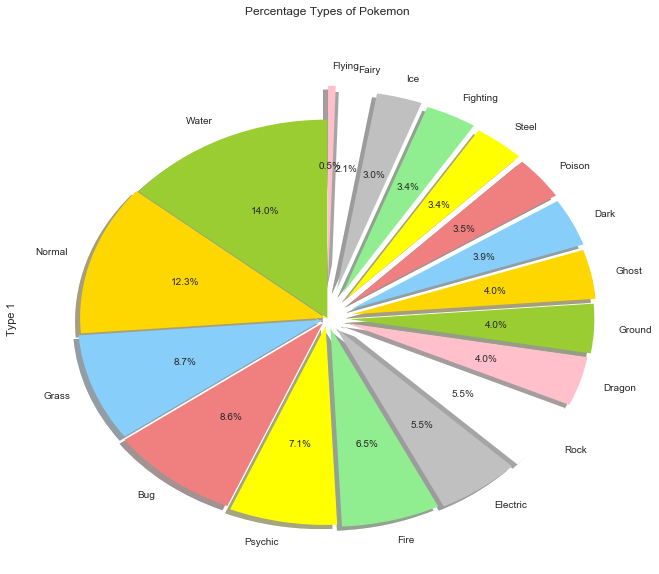

In [16]:
types = pkmn['Type 1']

colors = [
    'yellowgreen',
    'gold',
    'lightskyblue',
    'lightcoral',
    'yellow',
    'lightgreen',
    'silver',
    'white',
    'pink'
]


explode = np.arange(len(types.unique())) * 0.01
plt.figure(figsize=(20,30))
types.value_counts().plot.pie(
    explode=explode,
    colors=colors,
    title="Types of Pokemon",
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    figsize=(9,8)
)
plt.title("Percentage Types of Pokemon", y=1.1)
plt.tight_layout()

## Feature Engineering 

In [57]:
# Not interested in type 2.
del data['Type 2']
del data['Total']

# Create a binary response variable for each type and generation.
type1 = data.pop('Type 1')
response_values = pd.get_dummies(type1)
dummies_list = []
for x in response_values:
    word = 'Type_1_' + x
    dummies_list.append(word)
response_values.columns = dummies_list

gen = data.pop('Generation')
dummies_2 = pd.get_dummies(gen)
dummies1list = []
for x in dummies_2:
    word = 'Generation_' + str(x)
    dummies1list.append(word)
dummies_2.columns = dummies1list

In [58]:
# Finalising the dataset.
data = pd.concat([data, dummies_2], axis=1)

# Set the base case as a normal pokemon from the 6th generation.
del response_values['Type_1_Normal']
del data['Generation_6']
del data['Name']
#Converts the boolean column into a column of 0's and 1's.
data.Legendary = data.Legendary.astype(int)

## Modelling

In [76]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

#Creating training and test set with 80-20 split.
X_train, X_test, y_train, y_test = train_test_split(data, response_values, test_size = 0.2, random_state = 100)

#Normalise the features for some models
norm_train = preprocessing.normalize(X_train)
norm_test = preprocessing.normalize(X_test)

Models to try out are:

* Logistic Regression
* Naive Bayes
* Decision Trees
* Random Forest
* Adaptive Boosting
* Gradient Boosting

In [77]:
from sklearn.metrics import confusion_matrix, accuracy_score

def predictingModel(model):
    '''Computes accuracy and confusion matrices for models without normalised features.'''
    accuracy = []
    confusion_matrices = []
    for y_type in y_train:
        model.fit(X_train, (y_train[y_type]))
        pred = model.predict(X_test)
        confusion_matrices.append(confusion_matrix(y_test[y_type],pred))
        accuracy.append(accuracy_score(y_test[y_type],pred))
    return accuracy, confusion_matrices

In [78]:
def predictingModel2(model):
    '''Computes accuracy and confusion matrices for models with normalised features.'''
    accuracy = []
    confusion_matrices = []
    for y_type in y_train:
        model.fit(norm_train, (y_train[y_type]))
        pred = model.predict(norm_test)
        confusion_matrices.append(confusion_matrix(y_test[y_type],pred))
        accuracy.append(accuracy_score(y_test[y_type],pred))
    return accuracy, confusion_matrices

#### Logistic Regression

In [79]:
from sklearn.linear_model import LogisticRegression

# Logistic regression object.
Logistic_reg = LogisticRegression(random_state=15)
LG_A, LG_C = predictingModel(LogReg)

#### Naive Bayes

In [81]:
from sklearn.naive_bayes import GaussianNB

# Creates Naive Bayes object.
naive_bayes = GaussianNB()
# Making our final predictions on test set.
NB_A, NB_C = predictingModel2(naive_bayes)

#### Decision Trees

For the subsequent models, we have hyperparameters to tune. Therefore we use randomized search instead of grid search in order to save on computation time. This tries out random hyperparameters instead of all possible combination of hyperparameters, dramatically cutting down computation.

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Setup the parameters and distributions to sample from: param_dist
param_dist = {"max_depth": [5, None],
              "max_features": range(1, 9),
              "min_samples_leaf": range(1, 9),
              "criterion": ["gini", "entropy"]}

# Instantiate a Decision Tree classifier: tree
tree = DecisionTreeClassifier()

# Instantiate the RandomizedSearchCV object: tree_cv
tree_cv = RandomizedSearchCV(tree,param_dist, cv=10, scoring='accuracy', n_iter=10, random_state=5)

In [89]:
DT_A, DT_C = predictingModel(tree_cv)

/Users/ChristopherHyland/anaconda/lib/python3.6/site-packages/sklearn/model_selection/_split.py:597: Warning: The least populated class in y has only 3 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)


#### Random Forest

In [90]:
from sklearn.ensemble import RandomForestClassifier

# Setup the parameters and distributions to sample from: param_dist
param_dist = {"n_estimators": range(5,15),
              "max_depth": [3, None],
              "max_features": range(1, 9),
              "min_samples_split": range(2,5),
              "min_samples_leaf": range(1, 9),
              }

# Instantiate a Extremely Random Forest classifier: randext
randFor = RandomForestClassifier()

# Instantiate the RandomizedSearchCV object: randFor_cv
randFor_cv = RandomizedSearchCV(randFor,param_dist, cv=10, scoring='accuracy', n_iter=10, random_state=5)

In [91]:
RF_A, RF_C = predictingModel(randFor_cv)

/Users/ChristopherHyland/anaconda/lib/python3.6/site-packages/sklearn/model_selection/_split.py:597: Warning: The least populated class in y has only 3 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)


#### Adaptive Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Setup the parameters and distributions to sample from: param_dist
param_dist = {"n_estimators": range(330,400,10),
              "learning_rate": range(1,5),
              }

# Instantiate a Adaptie boosting classifier: tree
randAda = AdaBoostClassifier()

# Instantiate the RandomizedSearchCV object: randada_cv
randAda_cv = RandomizedSearchCV(randAda,param_dist, cv=10, scoring='accuracy', n_iter=10, random_state=5)

In [ ]:
AB_A, AB_C = predictingModel(randAda_cv)

#### Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Setup the parameters and distributions to sample from: param_dist
param_dist = {"loss": ["deviance", "exponential"],
              "n_estimators": range(250,550,50),
              "learning_rate": [0.1],
              "min_samples_split" : [2,4],
              "min_samples_leaf" : range(1,3)
              }

# Instantiate a GB boosting classifier: randGB
randGB = GradientBoostingClassifier()

# Instantiate the RandomizedSearchCV object: randGB_cv
randGB_cv = RandomizedSearchCV(randGB,param_dist, cv=10, scoring='accuracy', n_iter=10, random_state=5)

In [ ]:
GB_A, GB_C = predictingModel(randGB_cv)